# Notebook 3 — Baseline Evaluation and Comparative Analysis

## Objective

This notebook evaluates the outputs generated by Phi-4 and GPT-3.5 on the first example.

The evaluation compares each generated answer against the reference output using:
- deterministic text similarity metrics,
- simple structural quality checks,
- an LLM-based judge score.

The goal is to determine which model is closer to the expected answer and to summarize the trade-offs between quality, latency, and verbosity.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%pip install rouge-score nltk

%pip install bert-score

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('C:/Users/BRHN/Desktop/SLM-evals')

In [4]:
import os
import json
import math
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from openai import OpenAI
import mlflow
from mlflow.tracing import trace

* Initialize judge client
> We will use the OpenAI key as the judge for now.


In [5]:
load_dotenv(PROJECT_ROOT / ".env")

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

judge_client = OpenAI(api_key=OPENAI_API_KEY)

print("Judge client ready:", OPENAI_API_KEY is not None)

Judge client ready: True


## 1. Load Evaluation Inputs

We load:
- the golden dataset created in Notebook 1,
- the generated outputs created in Notebook 2.
- The golden dataset remains the source of truth for the reference answer.

In [6]:
golden_path = PROJECT_ROOT / "data" / "golden_v1.jsonl"

with open(golden_path, "r", encoding="utf-8") as f:
    golden_data = [json.loads(line) for line in f]

golden_data[0].keys()

dict_keys(['id', 'inputs', 'expectations', 'metadata'])

In [7]:
generated_outputs_path = PROJECT_ROOT / "outputs" / "tables" / "generated_outputs_baseline.csv"

outputs_df = pd.read_csv(generated_outputs_path)

outputs_df.head()

,id,model_label,provider,model_name,temperature,max_tokens,output_text,latency_ms,prompt_tokens,completion_tokens,total_tokens,finish_reason,reference_output
0,biat_case_001,phi4_azure,azure,Phi-4-experimentation-investment-nextgen,0.0,1200,### Executive Summary: Financial Analysis of B...,21738.1166,656,696,1352,stop,Executive Summary\n\nOver the 2021–2024 period...
1,biat_case_001,gpt35_openai,openai,gpt-3.5-turbo,0.0,1200,**Executive Summary:**\n\nBanque International...,8258.0759,656,579,1235,stop,Executive Summary\n\nOver the 2021–2024 period...


In [8]:
reference_map = {
    record["id"]: record["expectations"]["expected_response"]
    for record in golden_data
}

outputs_df["reference_output"] = outputs_df["id"].map(reference_map)

outputs_df[["id", "model_label", "reference_output"]].head()

,id,model_label,reference_output
0,biat_case_001,phi4_azure,Executive Summary\n\nOver the 2021–2024 period...
1,biat_case_001,gpt35_openai,Executive Summary\n\nOver the 2021–2024 period...


In [9]:
print("Rows in outputs_df:", len(outputs_df))
print("Unique ids:", outputs_df["id"].nunique())
print("Missing references:", outputs_df["reference_output"].isna().sum())
print("Missing outputs:", outputs_df["output_text"].isna().sum())

Rows in outputs_df: 2
Unique ids: 1
Missing references: 0
Missing outputs: 0


## 2. Deterministic Similarity Metrics

We begin with two classical metrics:

- **ROUGE-L**: measures overlap based on the longest common subsequence.
- **BLEU**: measures token overlap between generated text and reference text.

These metrics are useful as a baseline, but they do not fully capture semantic quality.

In [10]:
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

In [11]:
rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
smooth = SmoothingFunction().method1

In [12]:
def compute_rouge_l(reference: str, prediction: str) -> float:
    if not isinstance(reference, str) or not isinstance(prediction, str):
        return np.nan
    return rouge.score(reference, prediction)["rougeL"].fmeasure

def compute_bleu(reference: str, prediction: str) -> float:
    if not isinstance(reference, str) or not isinstance(prediction, str):
        return np.nan
    
    reference_tokens = reference.split()
    prediction_tokens = prediction.split()
    
    if len(prediction_tokens) == 0:
        return 0.0
    
    return sentence_bleu([reference_tokens], prediction_tokens, smoothing_function=smooth)

In [13]:
outputs_df["rougeL"] = outputs_df.apply(
    lambda row: compute_rouge_l(row["reference_output"], row["output_text"]),
    axis=1
)

outputs_df["bleu"] = outputs_df.apply(
    lambda row: compute_bleu(row["reference_output"], row["output_text"]),
    axis=1
)

outputs_df[["model_label", "rougeL", "bleu"]]

,model_label,rougeL,bleu
0,phi4_azure,0.313933,0.102761
1,gpt35_openai,0.285714,0.046395


- Phi-4 is closer to the reference text
- GPT-3.5 diverges more in wording and structure
- NOTE that ROUGE-L rewards STRUCTURE similarity, not INTELIGENCE
  > GPT-3.5 rewrites more freely , Phi-4 stays closer to wording of reference

The deterministic metrics (ROUGE-L and BLEU) indicate that Phi-4 produces outputs that are more closely aligned with the reference answer in terms of structure and wording.

Phi-4 achieves higher ROUGE-L and BLEU scores, suggesting better overlap with the reference text. This is consistent with its more detailed and structured output style.

However, BLEU scores remain relatively low for both models, which is expected in generative tasks where multiple valid phrasings exist.

These results highlight a limitation of lexical metrics: they reward similarity in wording rather than true semantic equivalence.

Therefore, these metrics should be complemented with semantic evaluation methods, such as LLM-based judging, to obtain a more complete assessment.

## 3. Simple Structural Quality Checks

In addition to text similarity, we evaluate whether the answer follows the expected report style.

These checks are intentionally simple and interpretable:
- output length,
- presence of a profitability section,
- presence of a conclusion,
- presence of risk-related discussion.

In [14]:
def contains_profitability(text: str) -> int:
    text = text.lower()
    keywords = ["profitability", "roe", "roa", "net income"]
    return int(any(k in text for k in keywords))

def contains_conclusion(text: str) -> int:
    text = text.lower()
    keywords = ["conclusion", "overall", "in conclusion"]
    return int(any(k in text for k in keywords))

def contains_risk_discussion(text: str) -> int:
    text = text.lower()
    keywords = ["risk", "npl", "cost of risk", "coverage ratio"]
    return int(any(k in text for k in keywords))

def normalized_length_score(prediction: str, reference: str) -> float:
    pred_len = len(prediction)
    ref_len = len(reference)
    if ref_len == 0:
        return 0.0
    ratio = pred_len / ref_len
    return max(0.0, 1.0 - abs(1.0 - ratio))

In [15]:
outputs_df["has_profitability"] = outputs_df["output_text"].apply(contains_profitability)
outputs_df["has_conclusion"] = outputs_df["output_text"].apply(contains_conclusion)
outputs_df["has_risk_discussion"] = outputs_df["output_text"].apply(contains_risk_discussion)
outputs_df["length_score"] = outputs_df.apply(
    lambda row: normalized_length_score(row["output_text"], row["reference_output"]),
    axis=1
)

outputs_df["structure_score"] = outputs_df[
    ["has_profitability", "has_conclusion", "has_risk_discussion"]
].mean(axis=1)

outputs_df[[
    "model_label",
    "has_profitability",
    "has_conclusion",
    "has_risk_discussion",
    "structure_score",
    "length_score"
]]

,model_label,has_profitability,has_conclusion,has_risk_discussion,structure_score,length_score
0,phi4_azure,1,1,1,1.0,0.576401
1,gpt35_openai,1,1,1,1.0,0.499363


- Phi-4 outputs are more similar to the reference in structure and length 

## 4. LLM-as-a-Judge Evaluation

We now introduce a judge model that compares each generated output to the reference answer.

The judge evaluates:
- factual correctness,
- completeness,
- clarity,
- alignment with the reference answer.

The score is normalized between 0 and 1.

In [16]:
def judge_output_with_llm(reference: str, prediction: str, client: OpenAI, judge_model: str = "gpt-4o"):
    prompt = f"""
You are an expert evaluator for financial analysis reports.

Your task is to compare a model-generated answer to a reference answer.

Score the generated answer on a scale from 0 to 1 according to:
1. Correctness of financial interpretation
2. Coverage of important points
3. Clarity and structure
4. Faithfulness to the provided reference

Return ONLY a valid JSON object in this exact format:
{{
  "score": 0.0,
  "reason": "short explanation"
}}

Reference answer:
\"\"\"
{reference}
\"\"\"

Generated answer:
\"\"\"
{prediction}
\"\"\"
""".strip()

    response = client.chat.completions.create(
        model=judge_model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.0,
        max_tokens=250
    )

    raw_text = response.choices[0].message.content.strip()

    try:
        parsed = json.loads(raw_text)
        score = float(parsed["score"])
        reason = parsed["reason"]
    except Exception:
        score = np.nan
        reason = raw_text

    return score, reason

In [17]:

judge_results = outputs_df.apply(
    lambda row: judge_output_with_llm(
        reference=row["reference_output"],
        prediction=row["output_text"],
        client=judge_client,
        judge_model="gpt-4.1-mini"
    ),
    axis=1
)

outputs_df[["judge_score", "judge_reason"]] = pd.DataFrame(
    judge_results.tolist(),
    index=outputs_df.index
)

outputs_df[["model_label", "judge_score", "judge_reason"]]

,model_label,judge_score,judge_reason
0,phi4_azure,0.9,The generated answer correctly interprets the ...
1,gpt35_openai,0.9,The generated answer correctly interprets the ...


## 5. Semantic Similarity with BERTScore

BERTScore complements ROUGE and BLEU by measuring semantic similarity rather than relying only on exact wording overlap.

In [18]:
from bert_score import score as bertscore_score
import re

def normalize_ws(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()

cands = outputs_df["output_text"].fillna("").map(normalize_ws).tolist()
refs = outputs_df["reference_output"].fillna("").map(normalize_ws).tolist()

P, R, F1 = bertscore_score(
    cands,
    refs,
    lang="en",
    rescale_with_baseline=True
)

outputs_df["bert_precision"] = [float(x) for x in P]
outputs_df["bert_recall"] = [float(x) for x in R]
outputs_df["bert_f1"] = [float(x) for x in F1]

outputs_df[["model_label", "bert_precision", "bert_recall", "bert_f1"]]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,model_label,bert_precision,bert_recall,bert_f1
0,phi4_azure,0.355425,0.245390,0.300964
1,gpt35_openai,0.274008,0.223307,0.249753


* Phi-4 > GPT-3.5 on semantic similarity

## 6. Build a Composite Evaluation View

We now combine deterministic metrics, structural checks, and judge scores in one comparison table.

In [19]:
comparison_cols = [
    "id",
    "model_label",
    "provider",
    "latency_ms",
    "prompt_tokens",
    "completion_tokens",
    "total_tokens",
    "rougeL",
    "bleu",
    "bert_f1",
    "has_profitability",
    "has_conclusion",
    "has_risk_discussion",
    "structure_score",
    "length_score",
    "judge_score"
]

comparison_df = outputs_df[comparison_cols].copy()
comparison_df

,id,model_label,provider,latency_ms,prompt_tokens,completion_tokens,total_tokens,rougeL,bleu,bert_f1,has_profitability,has_conclusion,has_risk_discussion,structure_score,length_score,judge_score
0,biat_case_001,phi4_azure,azure,21738.1166,656,696,1352,0.313933,0.102761,0.300964,1,1,1,1.0,0.576401,0.9
1,biat_case_001,gpt35_openai,openai,8258.0759,656,579,1235,0.285714,0.046395,0.249753,1,1,1,1.0,0.499363,0.9


In [20]:
summary_df = comparison_df.groupby("model_label", as_index=False).mean(numeric_only=True)
summary_df

,model_label,latency_ms,prompt_tokens,completion_tokens,total_tokens,rougeL,bleu,bert_f1,has_profitability,has_conclusion,has_risk_discussion,structure_score,length_score,judge_score
0,gpt35_openai,8258.0759,656.0,579.0,1235.0,0.285714,0.046395,0.249753,1.0,1.0,1.0,1.0,0.499363,0.9
1,phi4_azure,21738.1166,656.0,696.0,1352.0,0.313933,0.102761,0.300964,1.0,1.0,1.0,1.0,0.576401,0.9


## 7. Normalize Metrics for Comparative Visualization

To create a radar chart, all metrics must be on a comparable 0–1 scale.

Most metrics already fall within this range.
Latency is inverted so that lower latency becomes a better score.

In [21]:
def invert_minmax(series: pd.Series) -> pd.Series:
    if series.nunique() == 1:
        return pd.Series([1.0] * len(series), index=series.index)
    normalized = (series - series.min()) / (series.max() - series.min())
    return 1.0 - normalized

In [22]:
radar_df = summary_df.copy()

radar_df["latency_score"] = invert_minmax(radar_df["latency_ms"])

radar_metrics = [
    "rougeL",
    "bleu",
    "bert_f1",
    "length_score",
    "structure_score",
    "judge_score",
    "latency_score"
]

radar_df[["model_label"] + radar_metrics]

,model_label,rougeL,bleu,bert_f1,length_score,structure_score,judge_score,latency_score
0,gpt35_openai,0.285714,0.046395,0.249753,0.499363,1.0,0.9,1.0
1,phi4_azure,0.313933,0.102761,0.300964,0.576401,1.0,0.9,0.0


In [23]:
def plot_radar_from_summary(df: pd.DataFrame, model_col: str, metrics: list, title: str = "Evaluation Radar Chart"):
    labels = metrics
    num_vars = len(labels)

    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

    for _, row in df.iterrows():
        values = row[metrics].tolist()
        values += values[:1]

        ax.plot(angles, values, linewidth=2.5, label=row[model_col])
        ax.fill(angles, values, alpha=0.12)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=11)

    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=10)

    ax.set_rlabel_position(15)
    ax.grid(True, linestyle="dashed", alpha=0.5)

    ax.set_title(title, size=15, pad=25, weight="bold")
    ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1), frameon=False)

    plt.tight_layout()
    plt.show()

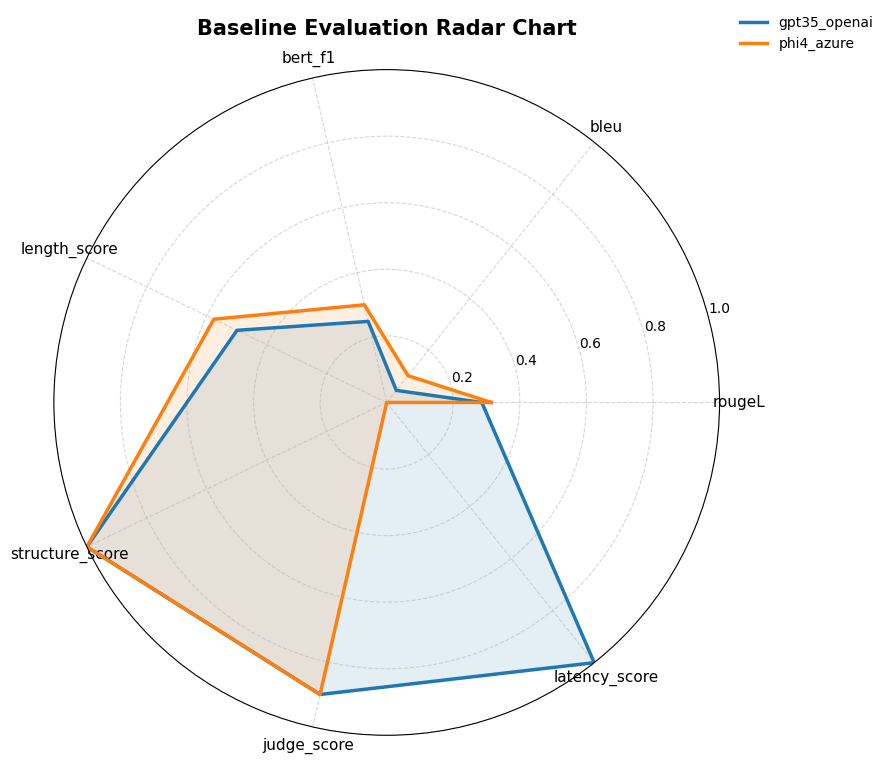

In [24]:
plot_radar_from_summary(
    radar_df,
    model_col="model_label",
    metrics=radar_metrics,
    title="Baseline Evaluation Radar Chart"
)

## Final Evaluation Interpretation

The evaluation shows that Phi-4 achieves stronger lexical and semantic similarity to the reference answer. It obtains higher ROUGE-L, BLEU, BERTScore, and length alignment, indicating that its output is closer to the reference in structure, wording, and semantic content.

At the same time, both models appear to be comparable under the LLM-based judge in the current run, suggesting that they deliver similar overall answer quality from the judge’s perspective.

The main remaining difference lies in operational efficiency: GPT-3.5 remains significantly faster, resulting in a much higher normalized latency score.

To simplify the comparative visualization, the individual binary structural checks were aggregated into a single `structure_score`. This score reflects the proportion of required analytical sections present in each answer.

The radar chart therefore shows that Phi-4 is stronger on similarity-based dimensions, while GPT-3.5 retains a clear advantage in latency. This indicates that Phi-4 is already competitive in content quality, but still weaker in runtime efficiency.

In [25]:
final_results_df = radar_df[[
    "model_label",
    "rougeL",
    "bleu",
    "bert_f1",
    "length_score",
    "structure_score",
    "judge_score",
    "latency_score"
]].copy()

for col in final_results_df.columns:
    if col != "model_label":
        final_results_df[col] = final_results_df[col].round(4)

final_results_df

,model_label,rougeL,bleu,bert_f1,length_score,structure_score,judge_score,latency_score
0,gpt35_openai,0.2857,0.0464,0.2498,0.4994,1.0,0.9,1.0
1,phi4_azure,0.3139,0.1028,0.3010,0.5764,1.0,0.9,0.0


## Saving the baseline evaluation CSV

In [26]:
eval_dir = PROJECT_ROOT / "outputs" / "tables"
eval_dir.mkdir(parents=True, exist_ok=True)

eval_csv_path = eval_dir / "baseline_evaluation_results.csv"
final_results_df.to_csv(eval_csv_path, index=False)

print("Saved evaluation results to:", eval_csv_path)

Saved evaluation results to: C:\Users\BRHN\Desktop\SLM-evals\outputs\tables\baseline_evaluation_results.csv


## Log the baseline run to MLflow

In [27]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("phi4_vs_gpt35_baseline")

with mlflow.start_run(run_name="baseline_phi4_vs_gpt35_biat_case"):
    mlflow.log_param("dataset_version", "golden_v1")
    mlflow.log_param("num_samples", len(outputs_df))
    mlflow.log_param("task", "financial_analysis_generation")
    mlflow.log_param("reference_case", "biat_case_001")
    mlflow.log_param("technique", "baseline")
    mlflow.log_param("judge_model", "gpt-4o")

    mlflow.set_tag("phase", "baseline")
    mlflow.set_tag("dataset", "golden_v1")
    mlflow.set_tag("task", "financial_analysis")
    mlflow.set_tag("models_compared", "phi4_vs_gpt35")
    
    for _, row in outputs_df.iterrows():
        prefix = row["model_label"]

        metric_cols = [
            "latency_ms",
            "prompt_tokens",
            "completion_tokens",
            "total_tokens",
            "rougeL",
            "bleu",
            "bert_f1",
            "length_score",
            "judge_score",
        ]

        if "structure_score" in outputs_df.columns:
            metric_cols.append("structure_score")

        for col in metric_cols:
            if col in row.index and pd.notna(row[col]):
                mlflow.log_metric(f"{prefix}_{col}", float(row[col]))
                
    
    mlflow.log_table(outputs_df, "outputs_table.json")
    mlflow.log_table(final_results_df, "baseline_summary_table.json")
    mlflow.log_artifact(str(eval_csv_path))

print("Baseline experiment logged successfully.")

🏃 View run baseline_single_case at: http://127.0.0.1:5000/#/experiments/1/runs/61682d319cf0435da70a2aa172418556
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Baseline experiment logged successfully.


In [28]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")

In [29]:
experiment = mlflow.get_experiment_by_name("phi4_vs_gpt35_baseline")
experiment.experiment_id

'1'